# Config


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv

from entsoe import EntsoePandasClient

load_dotenv()

# ENTSOE Token
entsoe_token = os.getenv("ENTSOE_API_TOKEN")

# ENTSOE Client
entsoe_client = EntsoePandasClient(api_key=entsoe_token)

# Fetch Actual & FCST Load

In [2]:
# Location
country_capital = "Madrid"
country_code = "ES"


# Period
today = pd.Timestamp.now(
    tz=f"Europe/{country_capital}"
).normalize()

yesterday=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=1)
)
last_week=(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    - pd.Timedelta(days=7)
)

tomorrow =(pd.Timestamp.now(tz=f"Europe/{country_capital}")
    .normalize()
    + pd.Timedelta(days=1)
)


start=last_week
end=today


# ENTSOE Client
df = entsoe_client.query_load_and_forecast(
    country_code=country_code,
    start=last_week,
    end=today)

# EDA

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 672 entries, 2026-09-05 00:00:00+02:00 to 2026-09-11 23:45:00+02:00
Freq: 15min
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Forecasted Load  672 non-null    float64
 1   Actual Load      671 non-null    float64
dtypes: float64(2)
memory usage: 31.9 KB


In [4]:
 df.describe().T

,count,mean,std,min,25%,50%,75%,max
Forecasted Load,672.0,30037.913690,3788.153532,23118.0,26877.5,30017.5,32909.25,37847.0
Actual Load,671.0,29854.962742,3883.108534,22772.0,26540.0,30020.0,32528.00,38628.0


In [5]:
df.head()

,Forecasted Load,Actual Load
2026-09-05 00:00:00+02:00,30191.0,30248.0
2026-09-05 00:15:00+02:00,29804.0,29896.0
2026-09-05 00:30:00+02:00,29405.0,29472.0
2026-09-05 00:45:00+02:00,29000.0,28836.0
2026-09-05 01:00:00+02:00,28573.0,28440.0


In [6]:
df.tail()

,Forecasted Load,Actual Load
2026-09-11 22:45:00+02:00,28841.0,27828.0
2026-09-11 23:00:00+02:00,28282.0,27632.0
2026-09-11 23:15:00+02:00,27804.0,27136.0
2026-09-11 23:30:00+02:00,27342.0,26408.0
2026-09-11 23:45:00+02:00,26903.0,NaN


In [7]:
# Check that timestamps are unique
assert df.index.is_unique

# Check that timestamps are sorted
assert df.index.is_monotonic_increasing

In [8]:
pivot = pd.pivot_table(
    df,
    values=["Actual Load", "Forecasted Load"],
    index=df.index.date,
    aggfunc="mean"
)

pivot["Delta"] = pivot["Actual Load"] - pivot["Forecasted Load"]

print(pivot.round(2))

            Actual Load  Forecasted Load   Delta
2026-09-05     29330.50         29346.51  -16.01
2026-09-06     27352.04         27432.54  -80.50
2026-09-07     32321.58         32199.40  122.19
2026-09-08     32491.96         32709.20 -217.24
2026-09-09     30528.17         31162.48 -634.31
2026-09-10     29087.21         28813.67  273.54
2026-09-11     27852.42         28601.60 -749.18


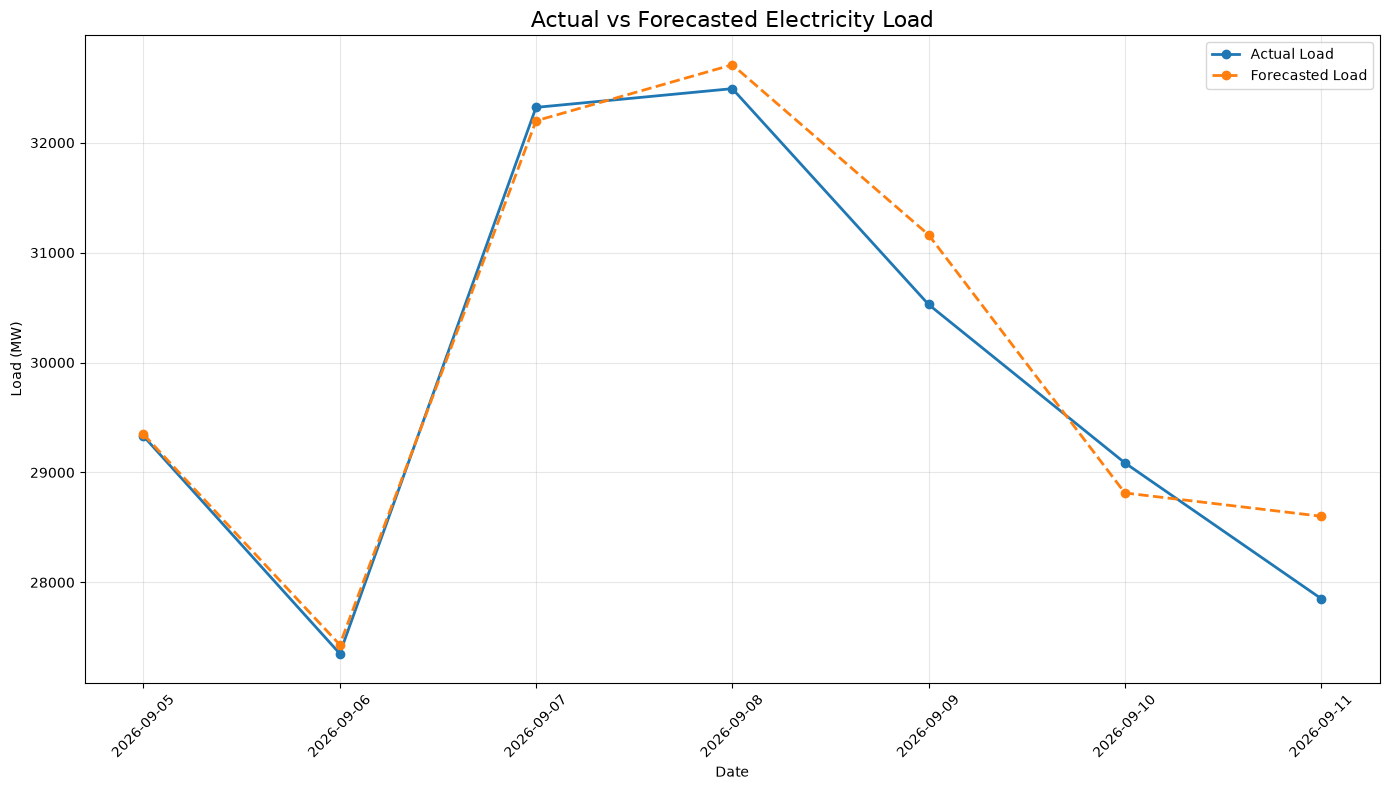

In [9]:
# Plot \Actual vs Forecasted Electricity Load/



plt.figure(figsize=(14, 8))

plt.plot(
    pivot.index,
    pivot["Actual Load"],
    marker="o",
    linewidth=2,
    label="Actual Load"
)

plt.plot(
    pivot.index,
    pivot["Forecasted Load"],
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Forecasted Load"
)

plt.title("Actual vs Forecasted Electricity Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

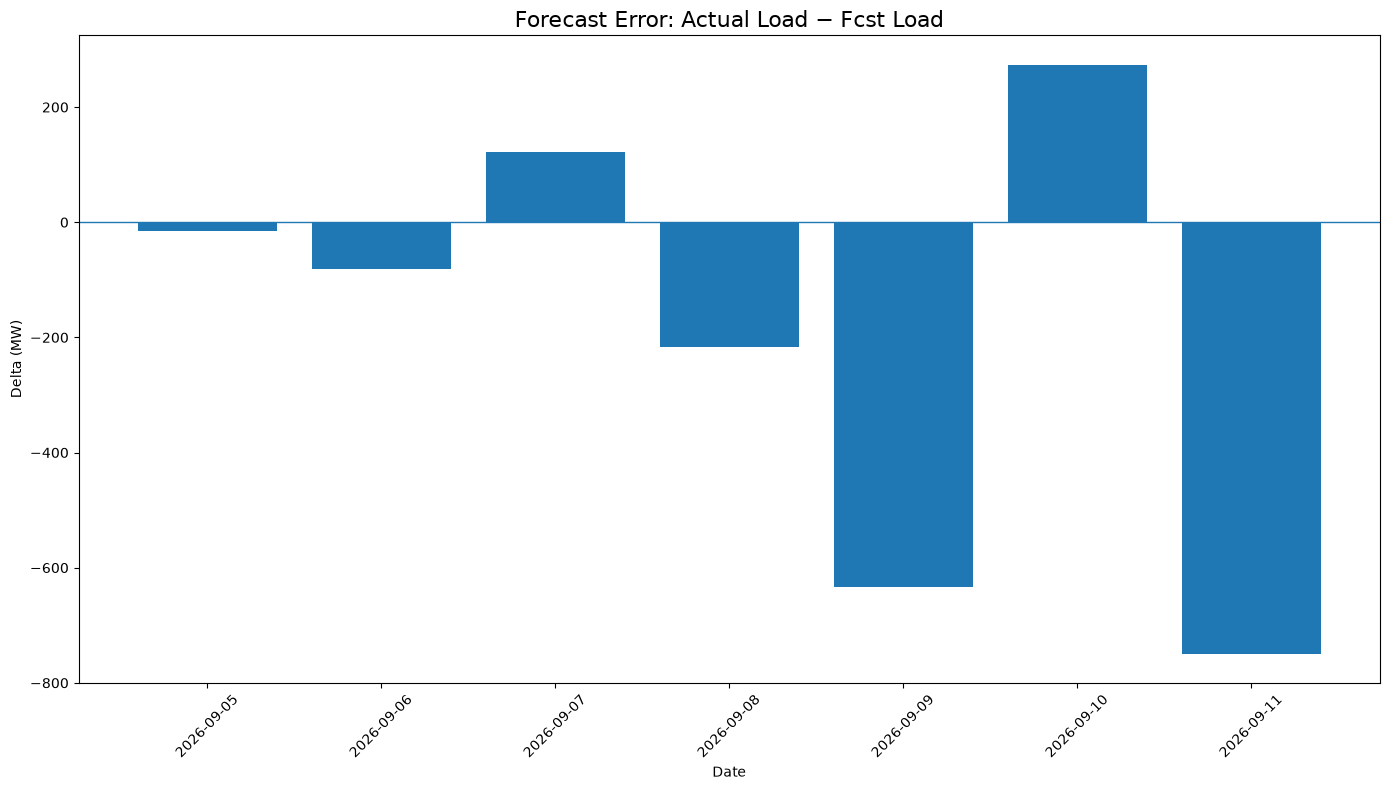

In [10]:
# Plot \Forecast Error: Actual Load − Fcst Load/

plt.figure(figsize=(14, 8))

plt.bar(
    pivot.index,
    pivot["Delta"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Forecast Error: Actual Load − Fcst Load", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Delta (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()